In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Work 2026/Junior Data Analyst/asos_inventory_analysis/products_asos.csv')
df.head()

,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [3]:
# Force the 'price' column to be numeric. If it hits text it can't convert, it turns it into a null value (NaN).
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop any rows where the price is null, as we cannot calculate lost revenue without a price.
df = df.dropna(subset=['price'])

# Print the remaining number of valid rows to confirm the drop worked.
print(f"Data loaded and cleaned: {len(df)} valid rows remain.")

Data loaded and cleaned: 18378 valid rows remain.


In [4]:
# 1. Define a list of core ASOS brands to look for
target_brands = ['asos design', 'new look', 'stradivarius', 'river island',
                 'topshop', 'mango', 'miss selfridge', 'pull&bear']

# 2. Create a function that checks if a target brand is inside the product name
def find_brand(product_name):
    name_lower = str(product_name).lower()
    for brand in target_brands:
        if brand in name_lower:
            return brand.title() # Capitalizes the brand name cleanly
    return 'Other' # If it's a tiny brand, label it 'Other'

# 3. Apply this function to every single row to create a new 'brand' column
df['brand'] = df['name'].apply(find_brand)

# 4. Count how many items belong to each brand to verify it worked
brand_counts = df['brand'].value_counts()
print(brand_counts.head(10))

brand
Other             10901
Asos Design        4209
Topshop            1136
River Island        474
New Look            469
Miss Selfridge      427
Stradivarius        345
Pull&Bear           266
Mango               151
Name: count, dtype: int64


In [5]:
# 1. Ensure the size column is text and convert it to lowercase for consistency
df['size'] = df['size'].astype(str).str.lower()

# 2. Count how many times 'out of stock' appears in the size text
df['stockout_count'] = df['size'].str.count('out of stock')

# 3. The Money Math: Multiply the price by the number of missing sizes
df['lost_revenue'] = df['price'] * df['stockout_count']

# 4. Group the data by brand to see the total lost revenue for each
brand_summary = df.groupby('brand').agg(
    total_items=('name', 'count'),          # How many total items they have
    avg_price=('price', 'mean'),            # Average cost of an item
    total_lost_revenue=('lost_revenue', 'sum') # Total money lost to stockouts
).reset_index()

# 5. Sort the results to show the brands losing the most money at the top
brand_summary = brand_summary.sort_values(by='total_lost_revenue', ascending=False)

# 6. Format the money column to look like actual currency for the executives
brand_summary['total_lost_revenue'] = brand_summary['total_lost_revenue'].apply(lambda x: f"${x:,.2f}")
brand_summary['avg_price'] = brand_summary['avg_price'].apply(lambda x: f"${x:,.2f}")

# Print the final business report
print(brand_summary)

            brand  total_items avg_price total_lost_revenue
4           Other        10901    $52.34        $786,844.26
0     Asos Design         4209    $39.73        $371,485.00
8         Topshop         1136    $47.61         $90,720.00
6    River Island          474    $45.30         $40,083.00
3        New Look          469    $28.55         $37,018.79
2  Miss Selfridge          427    $36.53         $27,302.08
7    Stradivarius          345    $30.33         $18,519.00
1           Mango          151    $46.46         $17,352.09
5       Pull&Bear          266    $29.29         $14,689.63


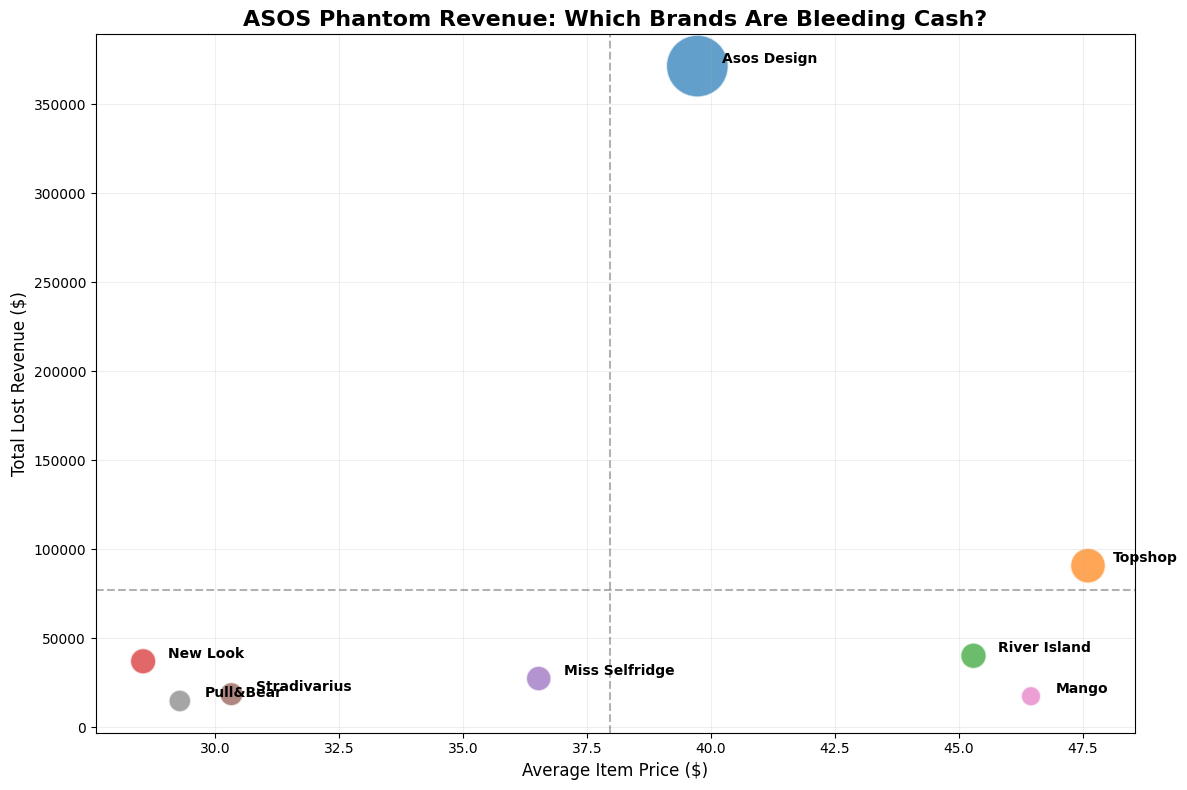

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter out 'Other' to focus on actionable named brands
chart_data = brand_summary[brand_summary['brand'] != 'Other'].copy()

# 2. Convert the formatted currency strings back to pure numbers for the graph
chart_data['revenue_num'] = chart_data['total_lost_revenue'].str.replace('$', '').str.replace(',', '').astype(float)
chart_data['price_num'] = chart_data['avg_price'].str.replace('$', '').str.replace(',', '').astype(float)

# 3. Build the scatter plot
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=chart_data,
    x='price_num',
    y='revenue_num',
    size='total_items',  # Bubble size represents how many items the brand has
    sizes=(200, 2000),
    alpha=0.7,
    hue='brand',
    legend=False
)

# 4. Add the brand names directly onto the bubbles
for i in range(chart_data.shape[0]):
    plt.text(
        x=chart_data['price_num'].iloc[i] + 0.5,
        y=chart_data['revenue_num'].iloc[i] + 2000,
        s=chart_data['brand'].iloc[i],
        fontsize=10,
        fontweight='bold'
    )

# 5. Draw the Quadrant lines (averages)
plt.axvline(x=chart_data['price_num'].mean(), color='black', linestyle='--', alpha=0.3)
plt.axhline(y=chart_data['revenue_num'].mean(), color='black', linestyle='--', alpha=0.3)

# 6. Format the chart
plt.title('ASOS Phantom Revenue: Which Brands Are Bleeding Cash?', fontsize=16, fontweight='bold')
plt.xlabel('Average Item Price ($)', fontsize=12)
plt.ylabel('Total Lost Revenue ($)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()